### ETL Process

1. Perform a complete ETL (Extract, Transform, Load) process.
2. Clean missing values, remove inconsistencies, and handle outliers.
3. Transform and integrate datasets for analysis.
4. Document the entire ETL pipeline clearly (tools, steps, assumptions).


In [6]:
import pandas as pd

# ------------
#   EXTRACT
# ------------
# Read CSV file
df = pd.read_csv('../data/Year 2010-2011.csv', encoding='ISO-8859-1')
print(f"Initial Rows: {df.shape[0]}")
print("Original Data:")
print(df.head())


Initial Rows: 541910
Original Data:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  Price  Customer ID         Country  
0  12/1/2010 8:26   2.55      17850.0  United Kingdom  
1  12/1/2010 8:26   3.39      17850.0  United Kingdom  
2  12/1/2010 8:26   2.75      17850.0  United Kingdom  
3  12/1/2010 8:26   3.39      17850.0  United Kingdom  
4  12/1/2010 8:26   3.39      17850.0  United Kingdom  


In [8]:
# Transform: Clean missing values, remove inconsistencies, and handle outliers.

# -------------
#   TRANSFORM
# -------------

# 1. Remove exact duplicates
df = df.drop_duplicates()

# 2. Filter out cancellations (Keep only rows where Invoice does NOT start with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 3. Keep only positive Quantities and Prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# 4. Drop rows where Customer ID is missing
df = df.dropna(subset=['Customer ID'])

# 5. Convert InvoiceDate to a proper Date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 6. Create Total_Revenue column
df['Total_Revenue'] = df['Quantity'] * df['Price']


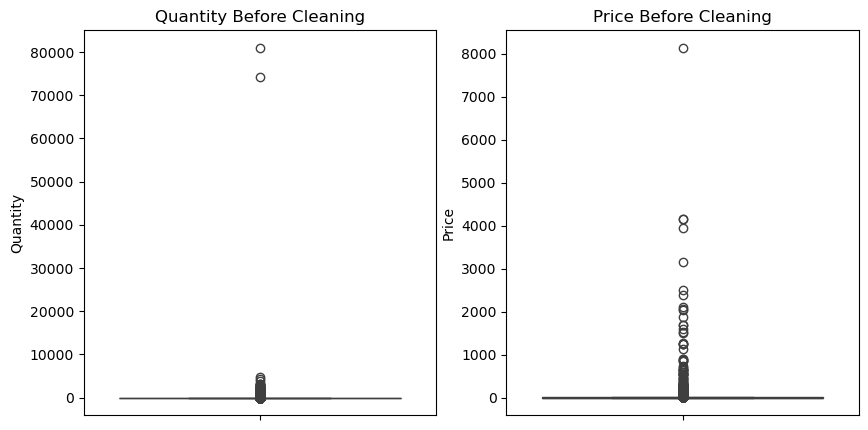

Data shape after removing statistical outliers: (333234, 9)


In [9]:
# Transform: Handle Outliers

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualize Outliers before cleaning (for your EDA report)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Quantity'])
plt.title('Quantity Before Cleaning')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Price'])
plt.title('Price Before Cleaning')
plt.show()

# 2. Define the IQR Function to find the "fences"
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    # Filter the data
    return df[(df[column] >= lower_fence) & (df[column] <= upper_fence)]

# 3. Apply the function to Quantity and Price
# We do this to ensure clustering and forecasting are not skewed by extreme values
df = remove_outliers(df, 'Quantity')
df = remove_outliers(df, 'Price')

print(f"Data shape after removing statistical outliers: {df.shape}")


In [11]:
# Integrate datasets for analysis.

# ------------
#    LOAD
# ------------
# Save the final cleaned data for the team
df.to_csv('../data/cleaned_retail_data.csv', index=False)

print("ETL process completed!")


ETL process completed!
